# Comparaison des performances des modèles

Ce notebook charge dynamiquement tous les fichiers `metrics.json` présents dans `ml_models/saved_models` et génère des visualisations pour comparer les modèles. Ces représentations nous aiderons à choisir le meilleur pour notre cas d'usage.

In [1]:
import json
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
import seaborn as sns
from math import pi

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_theme(style='whitegrid', palette='muted')

## 1. Chargement des métriques

In [2]:
SAVED_MODELS_DIR = os.path.join(os.path.dirname(os.path.abspath('__file__')), 'ml_models', 'saved_models')

records = []
for model_dir in sorted(os.listdir(SAVED_MODELS_DIR)):
    metrics_path = os.path.join(SAVED_MODELS_DIR, model_dir, 'metrics.json')
    if os.path.isfile(metrics_path):
        with open(metrics_path) as f:
            m = json.load(f)
        m['Model'] = model_dir.replace('_', ' ').title()
        m['model_key'] = model_dir
        records.append(m)

df = pd.DataFrame(records).set_index('Model')
df_display = df.drop(columns='model_key')
print(f"{len(df)} modèles chargés")
df_display.round(6)

6 modèles chargés


,MAE,MSE,RMSE,R2
Model,,,,
Elasticnet Regression,2.387171,8.976500,2.996081,0.998971
Gradient Boosting,2.428620,9.333005,3.054997,0.998938
Linear Regression,2.380023,8.923671,2.987251,0.998985
Mlp Regressor,2.410321,9.164358,3.027269,0.998958
Polynomial Linear Regression,2.389779,8.979275,2.996544,0.998970
Random Forest Regressor,3.038938,16.606936,4.075161,0.998111


## 2. Barres comparatives par métrique

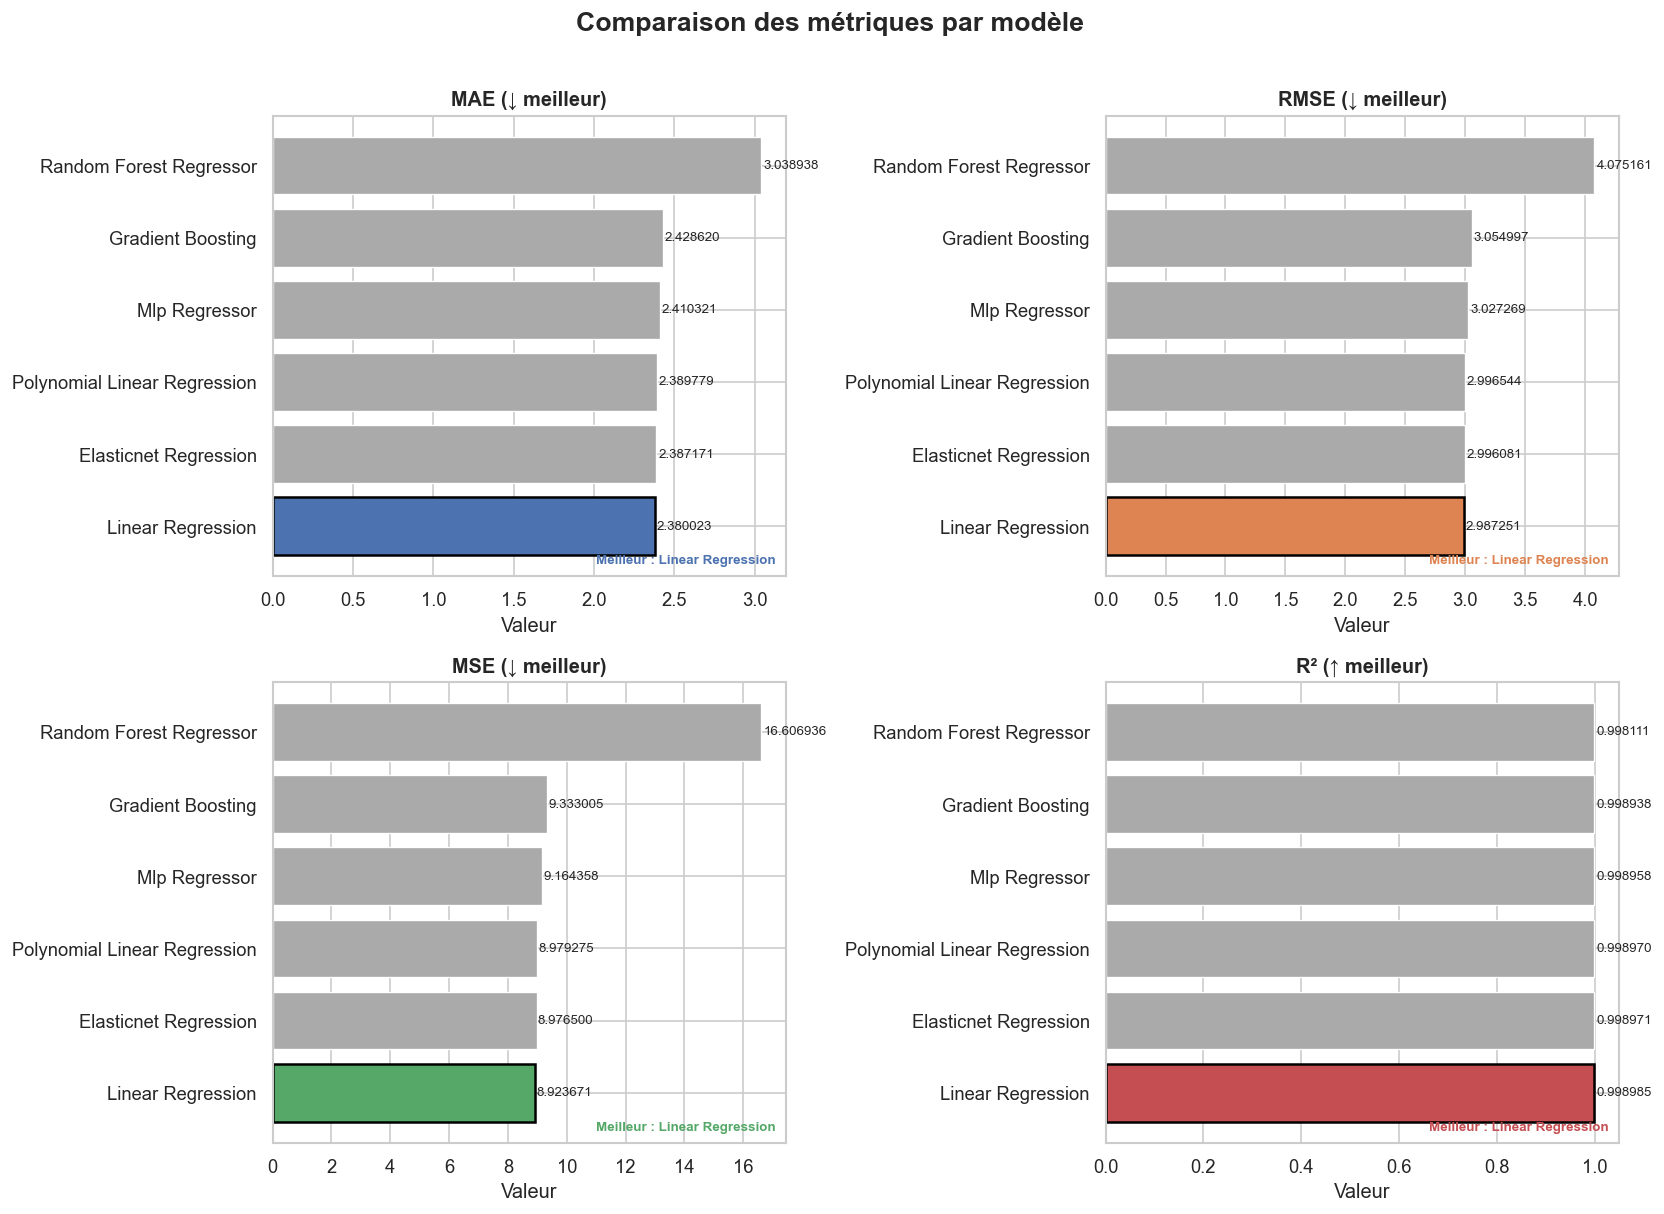

In [3]:
metrics_info = {
    'MAE':  {'label': 'MAE (↓ meilleur)',  'better': 'low',  'color': '#4C72B0'},
    'RMSE': {'label': 'RMSE (↓ meilleur)', 'better': 'low',  'color': '#DD8452'},
    'MSE':  {'label': 'MSE (↓ meilleur)',  'better': 'low',  'color': '#55A868'},
    'R2':   {'label': 'R² (↑ meilleur)',   'better': 'high', 'color': '#C44E52'},
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Comparaison des métriques par modèle', fontsize=16, fontweight='bold', y=1.01)

for ax, (metric, info) in zip(axes.flat, metrics_info.items()):
    vals = df_display[metric].sort_values(ascending=(info['better'] == 'low'))
    colors = [info['color'] if i == 0 else '#AAAAAA' for i in range(len(vals))]
    bars = ax.barh(vals.index, vals.values, color=colors, edgecolor='white', linewidth=0.8)
    for bar, val in zip(bars, vals.values):
        ax.text(bar.get_width() + bar.get_width() * 0.005, bar.get_y() + bar.get_height() / 2,
                f'{val:.6f}', va='center', fontsize=8)
    ax.set_title(info['label'], fontweight='bold')
    ax.set_xlabel('Valeur')
    best_label = f"Meilleur : {vals.index[0]}"
    ax.text(0.98, 0.02, best_label, transform=ax.transAxes, ha='right', va='bottom',
            fontsize=8, color=info['color'], fontweight='bold')
    # Highlight best bar
    bars[0].set_edgecolor('black')
    bars[0].set_linewidth(1.5)

plt.tight_layout()
plt.savefig('model_comparison_bars.png', bbox_inches='tight')
plt.show()

## 3. Graphique radar (Spider chart)

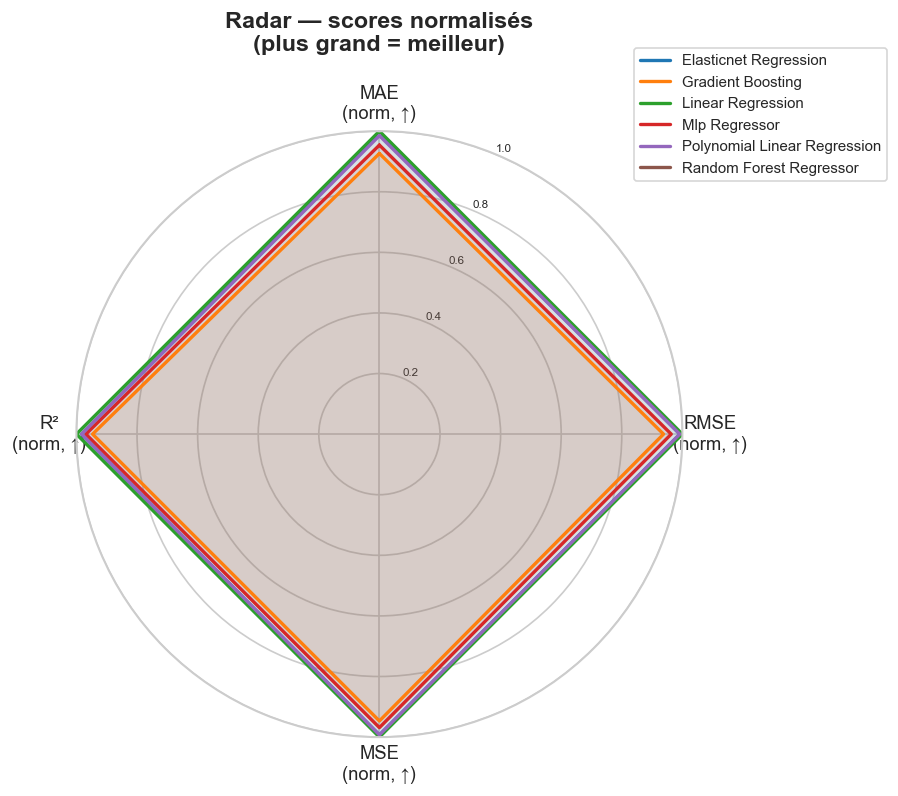

In [4]:
# Normalisation : pour les métriques d'erreur, on inverse (score = 1 - norm)
# pour que plus grand = meilleur sur tous les axes
radar_metrics = ['MAE', 'RMSE', 'MSE', 'R2']
df_norm = df_display[radar_metrics].copy()

for col in ['MAE', 'RMSE', 'MSE']:
    mn, mx = df_norm[col].min(), df_norm[col].max()
    if mx > mn:
        df_norm[col] = 1 - (df_norm[col] - mn) / (mx - mn)
    else:
        df_norm[col] = 1.0

col = 'R2'
mn, mx = df_norm[col].min(), df_norm[col].max()
if mx > mn:
    df_norm[col] = (df_norm[col] - mn) / (mx - mn)
else:
    df_norm[col] = 1.0

categories = radar_metrics
N = len(categories)
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]

palette = sns.color_palette('tab10', len(df_norm))

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
ax.set_theta_offset(pi / 2)
ax.set_theta_direction(-1)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(['MAE\n(norm, ↑)', 'RMSE\n(norm, ↑)', 'MSE\n(norm, ↑)', 'R²\n(norm, ↑)'], fontsize=11)
ax.set_ylim(0, 1)
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(['0.2', '0.4', '0.6', '0.8', '1.0'], fontsize=7)

for (model, row), color in zip(df_norm.iterrows(), palette):
    values = row.tolist() + row.tolist()[:1]
    ax.plot(angles, values, linewidth=2, linestyle='solid', label=model, color=color)
    ax.fill(angles, values, alpha=0.08, color=color)

ax.set_title('Radar — scores normalisés\n(plus grand = meilleur)', fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=9)
plt.tight_layout()
plt.savefig('model_comparison_radar.png', bbox_inches='tight')
plt.show()

## 4. Heatmap des métriques normalisées

C:\Users\dell\AppData\Local\Temp\ipykernel_9788\1431143667.py:4: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot_labels = annot_df.applymap(lambda x: f'{x:.6f}')


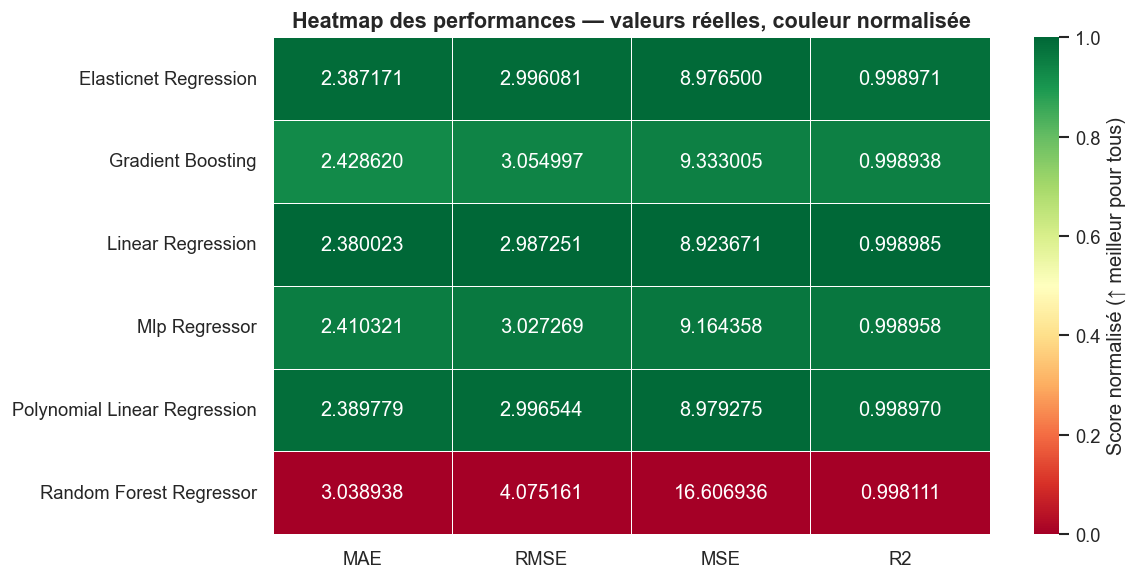

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

annot_df = df_display[radar_metrics].copy()
annot_labels = annot_df.applymap(lambda x: f'{x:.6f}')

sns.heatmap(
    df_norm[radar_metrics],
    annot=annot_labels,
    fmt='',
    cmap='RdYlGn',
    linewidths=0.5,
    ax=ax,
    vmin=0, vmax=1,
    cbar_kws={'label': 'Score normalisé (↑ meilleur pour tous)'}
)
ax.set_title('Heatmap des performances - valeurs réelles, couleur normalisée', fontsize=13, fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('')
plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('model_comparison_heatmap.png', bbox_inches='tight')
plt.show()

## 5. Score composite et classement final

In [6]:
# Score composite = moyenne des scores normalisés (tous ↑ meilleur)
df_norm['Score composite'] = df_norm[radar_metrics].mean(axis=1)
ranking = df_norm[['Score composite']].join(df_display).sort_values('Score composite', ascending=False)
ranking.index.name = 'Modèle'
ranking['Rang'] = range(1, len(ranking) + 1)
ranking = ranking[['Rang', 'Score composite', 'MAE', 'RMSE', 'MSE', 'R2']]

# Affichage stylisé
styled = ranking.style \
    .format({'Score composite': '{:.4f}', 'MAE': '{:.6f}', 'RMSE': '{:.6f}', 'MSE': '{:.6f}', 'R2': '{:.8f}'}) \
    .background_gradient(subset=['Score composite'], cmap='RdYlGn') \
    .set_caption('Classement final des modèles (Score composite = moyenne des 4 scores normalisés)') \
    .set_table_styles([{'selector': 'caption', 'props': [('font-size', '13px'), ('font-weight', 'bold')]}])
display(styled)

,Rang,Score composite,MAE,RMSE,MSE,R2
Modèle,,,,,,
Linear Regression,1,1.0000,2.380023,2.987251,8.923671,0.99898503
Elasticnet Regression,2,0.9894,2.387171,2.996081,8.976500,0.99897054
Polynomial Linear Regression,3,0.9881,2.389779,2.996544,8.979275,0.99897023
Mlp Regressor,4,0.9636,2.410321,3.027269,9.164358,0.99895766
Gradient Boosting,5,0.9394,2.428620,3.054997,9.333005,0.99893847
Random Forest Regressor,6,0.0000,3.038938,4.075161,16.606936,0.99811114


C:\Users\dell\AppData\Local\Temp\ipykernel_9788\3010124419.py:18: UserWarning: Glyph 129351 (\N{FIRST PLACE MEDAL}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\dell\AppData\Local\Temp\ipykernel_9788\3010124419.py:18: UserWarning: Glyph 129352 (\N{SECOND PLACE MEDAL}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\dell\AppData\Local\Temp\ipykernel_9788\3010124419.py:19: UserWarning: Glyph 129351 (\N{FIRST PLACE MEDAL}) missing from font(s) Arial.
  plt.savefig('model_comparison_ranking.png', bbox_inches='tight')
C:\Users\dell\AppData\Local\Temp\ipykernel_9788\3010124419.py:19: UserWarning: Glyph 129352 (\N{SECOND PLACE MEDAL}) missing from font(s) Arial.
  plt.savefig('model_comparison_ranking.png', bbox_inches='tight')
C:\Users\dell\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 129351 (\N{FIRST PLACE MEDAL}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\dell\AppData\Roaming\Pyt

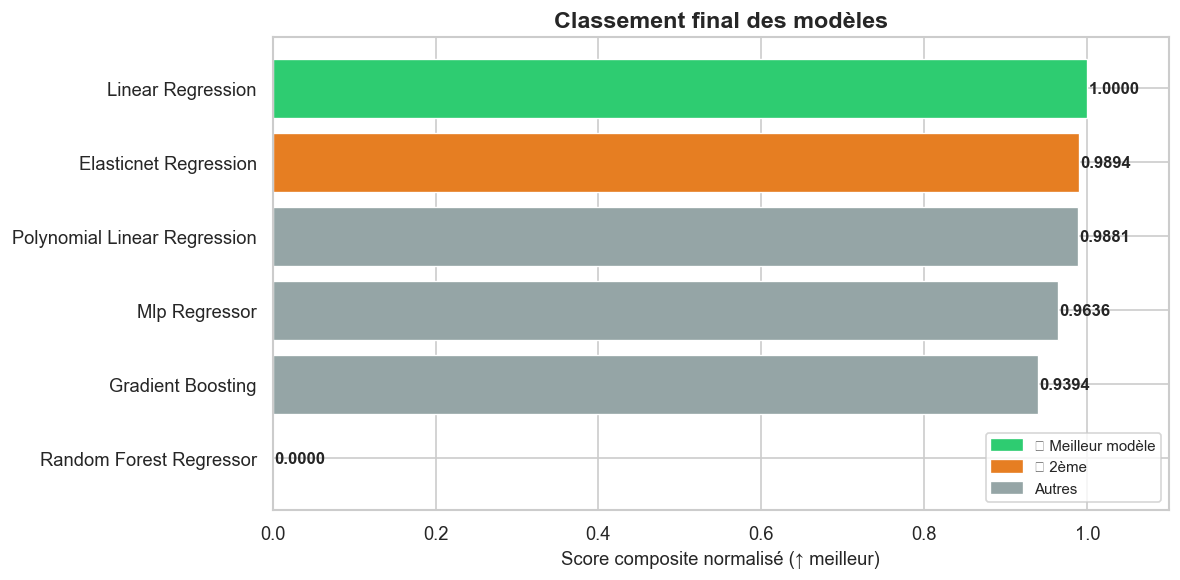

In [7]:
fig, ax = plt.subplots(figsize=(10, 5))
colors_rank = ['#2ecc71' if i == 0 else ('#e67e22' if i == 1 else '#95a5a6') for i in range(len(ranking))]
bars = ax.barh(ranking.index[::-1], ranking['Score composite'][::-1], color=colors_rank[::-1],
               edgecolor='white', linewidth=0.8)
for bar, val in zip(bars, ranking['Score composite'][::-1]):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height() / 2,
            f'{val:.4f}', va='center', fontsize=10, fontweight='bold')

ax.set_xlim(0, 1.1)
ax.set_xlabel('Score composite normalisé (↑ meilleur)', fontsize=11)
ax.set_title('Classement final des modèles', fontsize=14, fontweight='bold')
legend_patches = [
    mpatches.Patch(color='#2ecc71', label='🥇 Meilleur modèle'),
    mpatches.Patch(color='#e67e22', label='🥈 2ème'),
    mpatches.Patch(color='#95a5a6', label='Autres'),
]
ax.legend(handles=legend_patches, loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig('model_comparison_ranking.png', bbox_inches='tight')
plt.show()

## 6. Recommandation

In [8]:
best = ranking.index[0]
best_score = ranking.loc[best, 'Score composite']
best_r2    = ranking.loc[best, 'R2']
best_mae   = ranking.loc[best, 'MAE']
best_rmse  = ranking.loc[best, 'RMSE']

print('=' * 60)
print(f'  MODÈLE RECOMMANDÉ : {best}')
print('=' * 60)
print(f'  Score composite : {best_score:.4f}')
print(f'  R²              : {best_r2:.8f}')
print(f'  MAE             : {best_mae:.6f}')
print(f'  RMSE            : {best_rmse:.6f}')
print()
print('Classement complet :')
for i, (model, row) in enumerate(ranking.iterrows(), 1):
    print(f'  {i}. {model:<40} score={row["Score composite"]:.4f}')
print('=' * 60)

  MODÈLE RECOMMANDÉ : Linear Regression
  Score composite : 1.0000
  R²              : 0.99898503
  MAE             : 2.380023
  RMSE            : 2.987251

Classement complet :
  1. Linear Regression                        score=1.0000
  2. Elasticnet Regression                    score=0.9894
  3. Polynomial Linear Regression             score=0.9881
  4. Mlp Regressor                            score=0.9636
  5. Gradient Boosting                        score=0.9394
  6. Random Forest Regressor                  score=0.0000
